In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [7]:
def feature_normalize(X):
    """
    Normalize Features to have mean 0 and std 1

    X : (m,n) - not normalizing bias term

    Return : X_norm, mu, sigma

    """

    n = X.shape[1]
    X_norm = X.copy()
    mu = np.zeros(n)
    sigma = np.zeros(n)

    for i in range(1, n):
        mu[i] = np.mean(X[:,i])
        sigma[i] = np.std(X[:,i])
        try:
            X_norm[:,i] = (X[:,i] - mu[i]) / sigma[i]
        except:
            print(f"Error normalizing feature {i}")
    
    return X_norm, mu, sigma


    


In [8]:
#Testing
np.random.seed(42)
m = 100
feature1 = np.random.randn(m) * 1000 + 500      # Large range values
feature2 = np. random.randn(m) * 0.01 + 0.5     # small range values

X = np.c_[np.ones(m), feature1, feature2]

y = 3 + 0.5* feature1 - 200* feature2 + np.random.randn(m)*100 # Y = W.X + b + noise

print("Original feature ranges:")
print(f"Feature 1: [{X[:,1].min():.2f}, {X[:,1].max():.2f}]")
print(f"Feature 2: [{X[:,2].min():.4f}, {X[:,2].max():.4f}]")

X_norm, mu, sigma = feature_normalize(X)

print("\nNormalized feature ranges:")
print(f"Feature 1: [{X_norm[:,1].min():.2f}, {X_norm[:,1].max():.2f}]")
print(f"Feature 2: [{X_norm[:,2].min():.4f}, {X_norm[:,2].max():.4f}]")




Original feature ranges:
Feature 1: [-2119.75, 2352.28]
Feature 2: [0.4808, 0.5272]

Normalized feature ranges:
Feature 1: [-2.78, 2.16]
Feature 2: [-2.0456, 2.8432]


In [16]:
# comparing Gradient descent
def compare_gradient_descent(X, X_norm, y, alpha, num_iters):
    """
    Compare Gradient Descent with and without feature normalization

    X : (m,n) : original features
    X_norm : (m,n) : normalized features
    y : (m,) : target values
    theta : (n,) : parameters
    alpha : float : learning rate
    num_iters : int : number of iterations
    """

    m = len(y)
    n = X.shape[1]
    theta_unnorm = np.zeros(n)
    theta_norm = np.zeros(n)

    cost_history_unnorm = []
    cost_history_norm = []

    for i in range(num_iters):
        #unnormalized
        predictions_unnorm = X @ theta_unnorm
        error_unnorm = predictions_unnorm - y
        gradient_unnorm = (1/m) * X.T @ error_unnorm
        theta_unnorm = theta_unnorm - alpha * gradient_unnorm
        cost_unnorm = (1/(2*m)) * np.sum(error_unnorm**2)
        cost_history_unnorm.append(cost_unnorm)

        #normalized
        predictions_norm = X_norm @ theta_norm
        error_norm = predictions_norm - y
        gradient_norm = (1/m) * X_norm.T @ error_norm
        theta_norm = theta_norm - alpha * gradient_norm
        cost_norm = (1/2*m) * np.sum(error_norm**2)
        cost_history_norm.append(cost_norm)
    
    return cost_history_unnorm, cost_history_norm

/var/folders/hf/xwt_r03s7vldm1fspt0ls9400000gn/T/ipykernel_9621/3245596214.py:28: RuntimeWarning: overflow encountered in square
  cost_unnorm = (1/(2*m)) * np.sum(error_unnorm**2)
/var/folders/hf/xwt_r03s7vldm1fspt0ls9400000gn/T/ipykernel_9621/3245596214.py:26: RuntimeWarning: overflow encountered in matmul
  gradient_unnorm = (1/m) * X.T @ error_unnorm
/var/folders/hf/xwt_r03s7vldm1fspt0ls9400000gn/T/ipykernel_9621/3245596214.py:26: RuntimeWarning: invalid value encountered in matmul
  gradient_unnorm = (1/m) * X.T @ error_unnorm
/var/folders/hf/xwt_r03s7vldm1fspt0ls9400000gn/T/ipykernel_9621/3245596214.py:27: RuntimeWarning: invalid value encountered in subtract
  theta_unnorm = theta_unnorm - alpha * gradient_unnorm


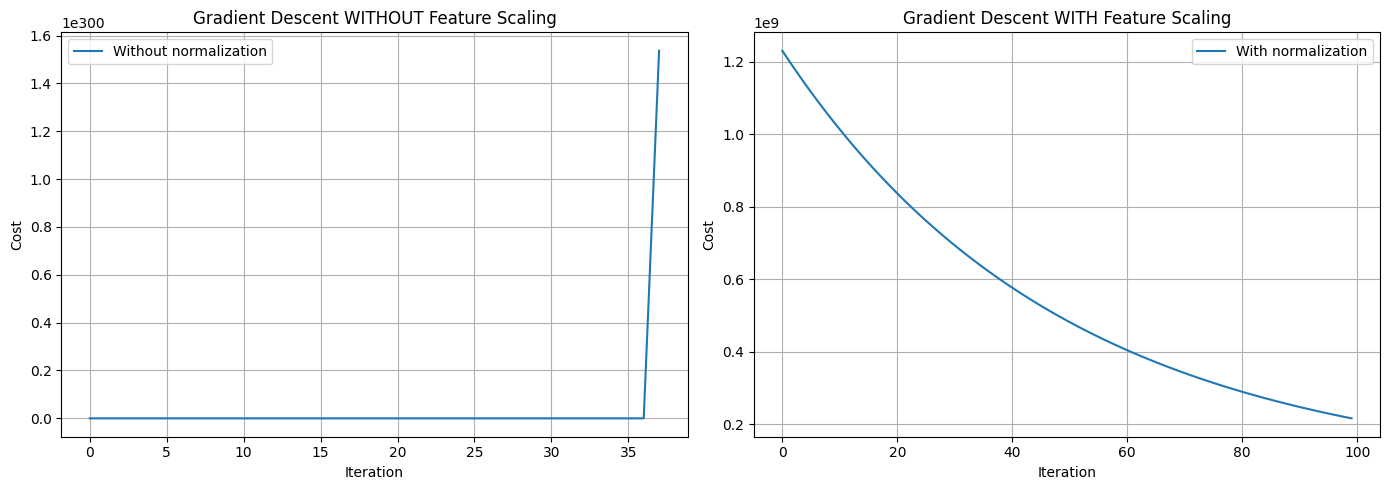


Final costs:
Without normalization: nan
With normalization: 216073896.03


In [17]:
# Testing

cost_h_unnorm, cost_h_norm = compare_gradient_descent(X, X_norm, y, alpha = 0.01, num_iters = 100)
# print(f"Theta Without Norm : {theta_unnorm}")
# print(f"Theta With Norm : {theta_norm}")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(cost_h_unnorm, label='Without normalization')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Cost')
ax1.set_title('Gradient Descent WITHOUT Feature Scaling')
ax1.legend()
ax1.grid(True)

ax2.plot(cost_h_norm, label='With normalization')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Cost')
ax2.set_title('Gradient Descent WITH Feature Scaling')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print("\nFinal costs:")
print(f"Without normalization: {cost_h_unnorm[-1]:.2f}")
print(f"With normalization: {cost_h_norm[-1]:.2f}")


# Here's exactly what you should expect to see:

## Without normalization — cost will explode or show nan because feature1 has values around 5000, making gradients enormous, and alpha=0.01 is way too large for that scale.

## With normalization — cost will drop smoothly and converge because both features are now on the same [-3, 3] scale.

* This is the whole point of the experiment — same alpha, same number of iterations, same data, only difference is normalization. The fact that one diverges and the other converges perfectly demonstrates why feature scaling matters in practice.
